## Key Simplifications

* **Reduced Network Depth:** Cut down from 5 blocks to just 3 convolutional blocks.
* **Fewer Parameters:** Decreased the number of filters (32→64→128 instead of 64→128→256→512→512).
* **Simpler Box Head:** Replaced the dual FC layers with a single FC layer.
* **Fewer Anchors:** Reduced anchor sizes from 5 to 3 scales.
* **Smaller Input Size:** Lowered the maximum image size from 1333 to 800 pixels.

## Anti-Overfitting Measures

* **Dropout Layers:** Added dropout after each convolutional block (2D spatial dropout) and in the box head.
* **Batch Normalization:** Maintained batch normalization to stabilize training.
* **L2 Regularization:** Added explicit L2 weight regularization during training.
* **Weight Initialization:** Implemented proper weight initialization with smaller values to improve stability.
* **Reduced Detections:** Lowered the maximum detections per image from 100 to 50.

The simplified model now strikes a better balance between:

* Having enough capacity to learn object detection patterns
* Avoiding excessive parameters that lead to overfitting
* Including multiple regularization techniques at different levels of the network

This approach is particularly beneficial for smaller datasets where overfitting is more likely to occur. The model maintains the same interface as before, so it can be used as a drop-in replacement while requiring less computational resources and being more resistant to overfitting.

In [1]:
import os
import sys
sys.path.append("../") # go to parent dir
%load_ext autoreload
%autoreload 2

In [2]:
from functions.loading_functions import *
train_df = get_dataset("train")
test_df = get_dataset("test")

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, average_precision_score
from datetime import datetime
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import box_iou
# Add signal handling for graceful termination
import signal
import sys

from functions.plotting_model_history import plot_training_history
import os
import shutil
import pandas as pd
from tqdm.notebook import tqdm
from functions.loading_functions import *
import cv2  # Import OpenCV for image manipulation
# Custom dataset forobject detection
class PlantRCNNDataset(Dataset):
    def __init__(self, df, class_map, transform=None, is_test=False):
        """
        Custom dataset for plant object detection with RCNN.
        
        Args:
            df: DataFrame with image paths and class info, including bounding box coordinates
            class_map: Dictionary mapping class names to indices
            transform: Image transformations to apply
            is_test: Whether this is a test dataset (no labels)
        """
        self.df = df
        self.class_map = class_map
        self.transform = transform
        self.is_test = is_test
        self.num_classes = len(class_map) + 1  # +1 for background class
        
        # Group by image ID to handle multiple objects per image
        self.image_ids = self.df['Image_ID'].unique()
        self.image_data = {}
        
        for img_id in self.image_ids:
            img_df = self.df[self.df['Image_ID'] == img_id]
            
            # Get image path (same for all rows with this image ID)
            img_path = img_df['ImagePath'].iloc[0]
            
            # Get all objects (bboxes and classes) for this image
            if not is_test:
                boxes = []
                labels = []
                confidences = []
                
                for _, row in img_df.iterrows():
                    # Extract bounding box coordinates
                    if all(coord in row for coord in ['xmin', 'ymin', 'xmax', 'ymax']):
                        box = [
                            float(row['xmin']), 
                            float(row['ymin']), 
                            float(row['xmax']), 
                            float(row['ymax'])
                        ]
                        
                        # Extract class label
                        class_name = row['class']
                        class_idx = self.class_map[class_name] + 1  # +1 because 0 is reserved for background
                        
                        # Extract confidence if available
                        confidence = float(row['confidence']) if 'confidence' in row else 1.0
                        
                        boxes.append(box)
                        labels.append(class_idx)
                        confidences.append(confidence)
                
                # Store all object data for this image
                self.image_data[img_id] = {
                    'path': img_path,
                    'boxes': boxes,
                    'labels': labels,
                    'confidences': confidences
                }
            else:
                # For test set, just store the image path
                self.image_data[img_id] = {
                    'path': img_path
                }
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.image_data[img_id]
        img_path = img_info['path']
        
        # Load image
        try:
            image = Image.open(img_path).convert('RGB')  # Ensure 3 channels
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a black image in case of error
            image = Image.new('RGB', (224, 224), color='black')
        
        # Get original image dimensions
        width, height = image.size
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
            
        # Check if the image has 3 channels, if not convert it
        if isinstance(image, torch.Tensor) and image.size(0) != 3:
            print(f"Warning: Image {img_path} has {image.size(0)} channels instead of 3. Converting to 3 channels.")
            # If grayscale (1 channel), repeat to make 3 channels
            if image.size(0) == 1:
                image = image.repeat(3, 1, 1)
            # If 2 or 4+ channels, take only the first 3 or pad with zeros
            elif image.size(0) == 2:
                zeros = torch.zeros_like(image[0]).unsqueeze(0)
                image = torch.cat([image, zeros], dim=0)
            elif image.size(0) > 3:
                image = image[:3]
        
        # Return image and target (or just image for test set)
        if self.is_test:
            return image, img_id
        else:
            # Convert boxes and labels to tensors
            if len(img_info['boxes']) > 0:
                boxes = torch.FloatTensor(img_info['boxes'])
                labels = torch.LongTensor(img_info['labels'])
                confidences = torch.FloatTensor(img_info['confidences'])
            else:
                # If no objects, create dummy values to avoid errors
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                labels = torch.zeros(0, dtype=torch.int64)
                confidences = torch.zeros(0, dtype=torch.float32)
            
            # RCNN target format
            target = {
                'boxes': boxes,
                'labels': labels,
                'confidences': confidences,
                'image_id': torch.tensor([idx])
            }
            
            return image, target

def collate_fn(batch):
    """
    Custom collate function for the DataLoader that handles
    variable-sized targets (different number of objects per image).
    """
    images = []
    targets = []
    
    for img, tgt in batch:
        images.append(img)
        targets.append(tgt)
    
    return images, targets

def prepare_data(df, test_df, img_size=224, batch_size=4):
    """
    Prepare data for training, validation, and testing.
    
    Args:
        df: DataFrame with image information including bounding boxes
        img_size: Size to resize images to
        batch_size: Batch size for data loaders
    
    Returns:
        train_loader, val_loader, test_loader, class_map, classes
    """
    # Create class mapping
    classes = sorted(df['class'].unique())
    class_map = {cls: i for i, cls in enumerate(classes)}
    
    # Define transforms with normalization
    train_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Split data into train, validation, and test sets
    # First get unique image IDs
    image_ids = df['Image_ID'].unique()
    train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=42)
    
    # Filter dataframe based on image IDs
    train_df = df[df['Image_ID'].isin(train_ids)]
    val_df = df[df['Image_ID'].isin(val_ids)]
    
    # Create datasets
    train_dataset = PlantRCNNDataset(train_df, class_map, transform=train_transform)
    val_dataset = PlantRCNNDataset(val_df, class_map, transform=val_transform)
    test_dataset = PlantRCNNDataset(test_df, class_map, transform=val_transform)
    
    # Determine number of workers based on available CPUs
    num_workers = min(4, os.cpu_count() or 0)  # Reduced worker count for stability
    
    # Create data loaders with multiprocessing settings adjusted
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size,
        shuffle=True, 
        num_workers=num_workers,
        collate_fn=collate_fn,  # Custom collate function for variable-sized targets
        persistent_workers=True if torch.cuda.is_available() else False,
        pin_memory=torch.cuda.is_available()
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        collate_fn=collate_fn,
        persistent_workers=True if torch.cuda.is_available() else False,
        pin_memory=torch.cuda.is_available()
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        collate_fn=collate_fn,
        persistent_workers=True if torch.cuda.is_available() else False,
        pin_memory=torch.cuda.is_available()
    )
    
    print(f"Train dataset: {len(train_dataset)} images")
    print(f"Validation dataset: {len(val_dataset)} images")
    print(f"Test dataset: {len(test_dataset)} images")
    print(f"Number of classes: {len(classes)}")
    print(f"Using {num_workers} worker threads for data loading")
    print(f"Images normalized with mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]")
    
    return train_loader, val_loader, test_loader, class_map, classes


def train_model(model, train_loader, val_loader, class_names, num_epochs=20, learning_rate=0.001,
                optimizer_name='sgd', early_stopping=True, patience=5, min_delta=0.001,
                log_interval=10, val_log_samples=5, use_multi_gpu=False, grad_clip=None, output_model_dir: str = None):
    """
    Train the RCNN model for object detection.
    
    Args:
        model: RCNN PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        class_names: List of class names
        num_epochs: Number of training epochs
        learning_rate: Learning rate
        optimizer_name: Name of optimizer to use ('adam', 'sgd', 'adamw', or 'rmsprop')
        early_stopping: Whether to use early stopping
        patience: Number of epochs to wait for improvement before stopping
        min_delta: Minimum change in validation mAP to qualify as improvement
        log_interval: How often (in batches) to log training metrics
        val_log_samples: Number of validation samples to log detailed predictions for
        use_multi_gpu: Whether to use multiple GPUs if available
        grad_clip: Maximum norm for gradient clipping (None for no clipping)
    
    Returns:
        Trained model and training history
    """
    
    def signal_handler(sig, frame):
        print('Ctrl+C detected, cleaning up...')
        # Clean up multiprocessing resources
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        sys.exit(0)
    
    # Register signal handler
    signal.signal(signal.SIGINT, signal_handler)
    
    # Use CUDA if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Move model to device and wrap with DataParallel if using multiple GPUs
    if use_multi_gpu and torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for training")
        model = nn.DataParallel(model)
    
    model = model.to(device)
    
    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Set multiprocessing start method if not already set
    import multiprocessing
    try:
        if not multiprocessing.get_start_method():
            multiprocessing.set_start_method('spawn')
    except RuntimeError:
        pass  # Method already set
    
    # Create optimizer based on name
    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=0.0005)
    elif optimizer_name.lower() == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.0005)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=0.0005)
    else:
        print(f"Warning: Optimizer {optimizer_name} not recognized. Using SGD as default.")
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=0.0005)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],  # Added val_loss to history
        'val_mAP': []
    }
    
    best_val_map = 0.0

    # Encode in the name of the model hyperparameters
    model_dir_name = f"{model._get_name()}_epochs_{num_epochs}_lr_{learning_rate}_optimizer_{optimizer_name}"

    if output_model_dir is None:
        raise ValueError("output_model_dir cannot be None. Please specify a valid directory.")
    # Make the model dir inside the output_model_dir
    else:
        model_dir = os.path.join(output_model_dir, model_dir_name)
        os.makedirs(model_dir, exist_ok=True)

        # name of best model is + datetime of date and time
        best_model_name = f"{model._get_name()}_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}_best_model.pth"

        # path to best model
        best_model_path = os.path.join(model_dir, best_model_name)

    # Early stopping variables
    early_stop_counter = 0
    
    # Training loop
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        
        # Training phase
        model.train()
        train_loss = 0.0
        count = 0
        batch_count = 0
        
        print(f"\nTraining Epoch {epoch+1}/{num_epochs}")
        for images, targets in train_loader:
            batch_count += 1
            # Move data to device
            images = [img.to(device) for img in images]
            targets_device = []
            
            for target in targets:
                target_device = {
                    'boxes': target['boxes'].to(device),
                    'labels': target['labels'].to(device),
                    'image_id': target['image_id'].to(device)
                }
                targets_device.append(target_device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass (returns loss dictionary)
            loss_dict = model(images, targets_device)
            losses = sum(loss for loss in loss_dict.values())
            
            # Backward pass and optimize
            losses.backward()
            
            # Apply gradient clipping if specified
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                
            optimizer.step()
            
            train_loss += losses.item()
            count += 1
            
            # Log detailed loss breakdown for some batches
            if batch_count % log_interval == 0:
                # Log training progress
                running_loss = train_loss / count
                print(f"  Batch {batch_count}/{len(train_loader)}, Running Loss: {running_loss:.4f}")
                print(f"  Loss Breakdown: ", end="")
                for k, v in loss_dict.items():
                    print(f"{k}: {v.item():.4f}  ", end="")
                print()
        
        # Calculate training loss for the epoch
        train_loss = train_loss / count if count > 0 else 0
        
        # Validation phase
        model.eval()
        print("\nStarting validation...")
        val_map, val_loss = evaluate_model_rcnn(model, val_loader, class_names, device, log_samples=val_log_samples, return_loss=True)
        
        # Update learning rate
        scheduler.step()
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)  # Store validation loss
        history['val_mAP'].append(val_map)
        
        # Print epoch results
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val mAP: {val_map:.4f}")
        print(f"Saving model to {best_model_path}")
        # Save best model based on mAP
        if val_map > best_val_map + min_delta:
            best_val_map = val_map
            try:
                torch.save(model.state_dict(), best_model_path)
                print(f"Saved best model with mAP: {val_map:.4f}")
            except OSError as e:
                print(f"Error saving model: {e}")
                return model, history

            # Reset early stopping counter if we found a better model
            early_stop_counter = 0
        else:
            # Increment early stopping counter if we didn't improve enough
            early_stop_counter += 1
            
        # Check if we should stop early
        if early_stopping and early_stop_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    
    # Load best model
    model.load_state_dict(torch.load(best_model_path))
    
    # Save the model path and name to history
    history['model_path'] = best_model_path
    history["model_name"] = best_model_path.split("/")[-1]
    history["model_dir"] = model_dir

    return model, history

def evaluate_model_rcnn(model, data_loader, class_names, device, log_samples=5, log_images=True, return_loss=False):
    """
    Evaluate the RCNN model using mAP (Mean Average Precision) and optionally calculate validation loss.
    
    Args:
        model: RCNN PyTorch model
        data_loader: Validation or test data loader
        class_names: List of class names
        device: Device to run the evaluation on
        log_samples: Number of image samples to log detailed predictions for
        log_images: Whether to save visualization of predictions vs ground truth
        return_loss: Whether to calculate and return validation loss
    
    Returns:
        mAP score if return_loss is False, otherwise (mAP score, validation loss)
        If ground truth labels are not available, returns predictions and 0 for mAP
    """
    model.eval()
    
    # Lists to store predictions and ground truth for mAP calculation
    all_predictions = []
    all_ground_truth = []
    
    # For validation loss calculation
    val_loss_sum = 0.0
    val_count = 0
    
    sample_counter = 0
    has_ground_truth = True
    
    print("\n===== VALIDATION LOGS =====")
    
    with torch.no_grad():
        for batch in data_loader:
            # Check if data_loader returns images and targets, or just images
            if isinstance(batch, (list, tuple)) and len(batch) == 2:
                images, targets = batch
                has_ground_truth = True
            else:
                images = batch
                targets = None
                has_ground_truth = False
                
            images = [img.to(device) for img in images]
            
            # Calculate validation loss only if we have ground truth and return_loss is requested
            if has_ground_truth and return_loss:
                targets_device = []
                for target in targets:
                    target_device = {
                        'boxes': target['boxes'].to(device),
                        'labels': target['labels'].to(device),
                        'image_id': target['image_id'].to(device) if 'image_id' in target else None
                    }
                    targets_device.append(target_device)
                
                try:
                    # Calculate validation loss by temporarily setting the model to training mode
                    # to get the loss dictionary
                    model.train()
                    loss_dict = model(images, targets_device)
                    model.eval()  # Switch back to eval mode
                    
                    # Sum up the loss values
                    val_batch_loss = sum(loss for loss in loss_dict.values())
                    val_loss_sum += val_batch_loss.item()
                    val_count += 1
                except Exception as e:
                    print(f"Warning: Could not calculate validation loss: {e}")
                    model.eval()  # Ensure model is back in eval mode
            
            # Get model predictions
            predictions = model(images)
            
            # Process each image's predictions and ground truth
            for i, pred in enumerate(predictions):
                # Get predictions
                pred_boxes = pred['boxes']
                pred_scores = pred['scores']
                pred_labels = pred['labels']
                
                # Store predictions
                all_predictions.append({
                    'boxes': pred_boxes,
                    'scores': pred_scores,
                    'labels': pred_labels
                })
                
                # Store ground truth if available
                if has_ground_truth:
                    gt_boxes = targets[i]['boxes'].to(device)
                    gt_labels = targets[i]['labels'].to(device)
                    
                    all_ground_truth.append({
                        'boxes': gt_boxes,
                        'labels': gt_labels
                    })
                
                # Log detailed info for a few samples
                if sample_counter < log_samples:
                    if has_ground_truth:
                        image_id = targets[i]['image_id'].item() if 'image_id' in targets[i] else sample_counter
                    else:
                        image_id = sample_counter
                    
                    print(f"\n----- Sample {sample_counter+1}/{log_samples} (Image ID: {image_id}) -----")
                    
                    # Log ground truth if available
                    if has_ground_truth:
                        print("GROUND TRUTH:")
                        if len(gt_labels) == 0:
                            print("  No ground truth annotations for this image")
                        else:
                            for j in range(len(gt_labels)):
                                class_idx = gt_labels[j].item() - 1  # -1 because class_map adds 1 to indices
                                class_name = class_names[class_idx] if 0 <= class_idx < len(class_names) else "Unknown"
                                box = gt_boxes[j].cpu().numpy()
                                print(f"  Class: {class_name} ({gt_labels[j].item()}), Box: [{box[0]:.1f}, {box[1]:.1f}, {box[2]:.1f}, {box[3]:.1f}]")
                    else:
                        print("GROUND TRUTH: Not available")
                    
                    # Log predictions
                    print("PREDICTIONS:")
                    # Filter predictions with score > 0.3 for logging
                    high_score_indices = (pred_scores > 0.3).nonzero().squeeze(dim=1)
                    if len(high_score_indices) > 0:
                        filtered_boxes = pred_boxes[high_score_indices]
                        filtered_scores = pred_scores[high_score_indices]
                        filtered_labels = pred_labels[high_score_indices]
                        
                        for j in range(len(filtered_scores)):
                            class_idx = filtered_labels[j].item() - 1  # -1 because class_map adds 1 to indices
                            class_name = class_names[class_idx] if 0 <= class_idx < len(class_names) else "Unknown"
                            box = filtered_boxes[j].cpu().numpy()
                            score = filtered_scores[j].item()
                            print(f"  Class: {class_name} ({filtered_labels[j].item()}), "
                                  f"Confidence: {score:.3f}, "
                                  f"Box: [{box[0]:.1f}, {box[1]:.1f}, {box[2]:.1f}, {box[3]:.1f}]")
                    else:
                        print("  No predictions with confidence > 0.3")
                    
                    # Display confusion matrix for this image if ground truth is available
                    if has_ground_truth and len(gt_labels) > 0 and len(pred_labels) > 0:
                        print("PREDICTION VS GROUND TRUTH ANALYSIS:")
                        # For each ground truth, find the best matching prediction
                        gt_matched = [False] * len(gt_labels)
                        pred_matched = [False] * len(pred_labels)
                        
                        # Best match for each ground truth
                        for j, gt_label in enumerate(gt_labels):
                            gt_box = gt_boxes[j]
                            gt_class_idx = gt_label.item() - 1
                            gt_class_name = class_names[gt_class_idx] if 0 <= gt_class_idx < len(class_names) else "Unknown"
                            
                            best_iou = 0.0
                            best_pred_idx = -1
                            
                            # Find best prediction for this ground truth
                            for k, pred_label in enumerate(pred_labels):
                                if pred_scores[k] < 0.3:  # Skip low confidence predictions
                                    continue
                                    
                                pred_box = pred_boxes[k]
                                
                                # Calculate IoU
                                iou = box_iou(gt_box.unsqueeze(0), pred_box.unsqueeze(0)).item()
                                
                                if iou > best_iou:
                                    best_iou = iou
                                    best_pred_idx = k
                            
                            # If found a match with IoU > 0.5
                            if best_iou > 0.5 and best_pred_idx >= 0:
                                pred_class_idx = pred_labels[best_pred_idx].item() - 1
                                pred_class_name = class_names[pred_class_idx] if 0 <= pred_class_idx < len(class_names) else "Unknown"
                                pred_score = pred_scores[best_pred_idx].item()
                                
                                # Check if class matches
                                class_match = gt_label.item() == pred_labels[best_pred_idx].item()
                                
                                print(f"  GT: {gt_class_name} -> Pred: {pred_class_name} "
                                      f"(Conf: {pred_score:.3f}, IoU: {best_iou:.3f}, "
                                      f"Class Match: {'✓' if class_match else '✗'})")
                                
                                gt_matched[j] = True
                                pred_matched[best_pred_idx] = True
                            else:
                                print(f"  GT: {gt_class_name} -> No matching prediction (IoU < 0.5)")
                        
                        # False negatives (unmatched ground truths)
                        false_negatives = sum(1 for m in gt_matched if not m)
                        if false_negatives > 0:
                            print(f"  False Negatives: {false_negatives} (ground truths with no matching predictions)")
                        
                        # False positives (unmatched predictions with high confidence)
                        high_conf_unmatched = sum(1 for k, m in enumerate(pred_matched) if not m and pred_scores[k] > 0.3)
                        if high_conf_unmatched > 0:
                            print(f"  False Positives: {high_conf_unmatched} (high confidence predictions with no matching ground truth)")
                    
                    # Visualize predictions vs ground truth if requested
                    if log_images and images[i] is not None:
                        try:
                            # Convert tensor to numpy image
                            img_tensor = images[i].cpu().clone()
                            # Denormalize if needed
                            # Note: assuming normalization with mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                            img_tensor = img_tensor * std + mean
                            img_tensor = img_tensor.clamp(0, 1)
                            
                            # Convert to numpy and change to HxWxC format
                            img_np = img_tensor.permute(1, 2, 0).numpy()
                            img_np = (img_np * 255).astype(np.uint8)
                            
                            # Create visualization
                            viz_img = img_np.copy()
                            
                            # Draw ground truth boxes in green if available
                            if has_ground_truth:
                                for j in range(len(gt_labels)):
                                    box = gt_boxes[j].cpu().numpy().astype(int)
                                    class_idx = gt_labels[j].item() - 1
                                    class_name = class_names[class_idx] if 0 <= class_idx < len(class_names) else "Unknown"
                                    cv2.rectangle(viz_img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
                                    cv2.putText(viz_img, f"GT: {class_name}", (box[0], box[1]-10), 
                                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                            
                            # Draw predicted boxes in blue for high confidence predictions
                            high_score_indices = (pred_scores > 0.3).nonzero().squeeze(dim=1)
                            if len(high_score_indices) > 0:
                                filtered_boxes = pred_boxes[high_score_indices].cpu().numpy().astype(int)
                                filtered_scores = pred_scores[high_score_indices].cpu().numpy()
                                filtered_labels = pred_labels[high_score_indices].cpu().numpy()
                                
                                for j in range(len(filtered_scores)):
                                    box = filtered_boxes[j]
                                    class_idx = filtered_labels[j] - 1
                                    class_name = class_names[class_idx] if 0 <= class_idx < len(class_names) else "Unknown"
                                    score = filtered_scores[j]
                                    
                                    cv2.rectangle(viz_img, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 2)
                                    cv2.putText(viz_img, f"Pred: {class_name} ({score:.2f})", 
                                               (box[0], box[3]+20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
                            
                            # Save image
                            output_dir = 'validation_viz'
                            os.makedirs(output_dir, exist_ok=True)
                            cv2.imwrite(f"{output_dir}/sample_{sample_counter+1}_id_{image_id}.jpg", cv2.cvtColor(viz_img, cv2.COLOR_RGB2BGR))
                            print(f"  Visualization saved to {output_dir}/sample_{sample_counter+1}_id_{image_id}.jpg")
                            
                        except Exception as e:
                            print(f"  Error creating visualization: {e}")
                    
                    sample_counter += 1
                    
                    # Calculate IoU between predictions and ground truth if available
                    if has_ground_truth and len(pred_boxes) > 0 and len(gt_boxes) > 0:
                        # Get top 5 predictions by confidence
                        topk = min(5, len(pred_boxes))
                        top_indices = torch.argsort(pred_scores, descending=True)[:topk]
                        top_boxes = pred_boxes[top_indices]
                        
                        # Calculate IoU matrix (top predictions x all ground truths)
                        ious = box_iou(top_boxes, gt_boxes)
                        
                        print("IoU MATRIX (Top predictions x Ground truths):")
                        for j in range(min(3, ious.shape[0])):  # Log up to 3 predictions
                            for k in range(min(3, ious.shape[1])):  # Log up to 3 ground truths
                                print(f"  Pred {j+1} vs GT {k+1}: {ious[j, k]:.3f}")
    
    print("===== END VALIDATION LOGS =====\n")
    
    # Calculate mAP only if ground truth is available
    if has_ground_truth:
        map_score = calculate_map_rcnn(all_predictions, all_ground_truth, len(class_names) + 1)
    else:
        print("No ground truth data available, cannot calculate mAP score.")
        map_score = 0.0
    
    # Calculate average validation loss if requested and available
    if return_loss:
        val_loss = val_loss_sum / val_count if val_count > 0 else 0
        print(f"Validation Loss: {val_loss:.4f}" if val_count > 0 else "Validation Loss: Not available")
        return map_score, val_loss
    else:
        return map_score

def calculate_map_rcnn(predictions, ground_truth, num_classes, iou_threshold=0.5):
    """
    Calculate mAP for object detection based on predictions and ground truth.
    
    Args:
        predictions: List of prediction dictionaries
        ground_truth: List of ground truth dictionaries
        num_classes: Number of classes (including background)
        iou_threshold: IoU threshold for considering a prediction correct
    
    Returns:
        mAP score
    """
    print(f"\n===== mAP CALCULATION (IoU threshold: {iou_threshold}) =====")
    print(f"Total images: {len(predictions)}")
    print(f"Number of classes: {num_classes-1} (excluding background)")
    
    # Initialize variables for mAP calculation
    aps = []
    
    # Calculate AP for each class (skipping the background class)
    for class_id in range(1, num_classes):  # Start from 1 to skip background
        # Lists to store true positives, false positives, and false negatives
        all_detections = []
        all_ground_truths = []
        
        # Collect all detections and ground truths for this class
        for i in range(len(predictions)):
            pred = predictions[i]
            gt = ground_truth[i]
            
            # Get pred_boxes and scores for this class
            class_mask = pred['labels'] == class_id
            pred_boxes = pred['boxes'][class_mask]
            pred_scores = pred['scores'][class_mask]
            
            # Create detections for mAP calculation (box + score)
            for j in range(len(pred_boxes)):
                all_detections.append({
                    'image_id': i,
                    'bbox': pred_boxes[j],
                    'score': pred_scores[j]
                })
            
            # Get ground truth boxes for this class
            gt_mask = gt['labels'] == class_id
            gt_boxes = gt['boxes'][gt_mask]
            
            for j in range(len(gt_boxes)):
                all_ground_truths.append({
                    'image_id': i,
                    'bbox': gt_boxes[j],
                    'used': False  # To mark ground truths that have been matched
                })
        
        # If no ground truths for this class, skip
        if len(all_ground_truths) == 0:
            continue
        
        # Sort detections by confidence score
        all_detections = sorted(all_detections, key=lambda x: x['score'], reverse=True)
        
        # Variables for precision-recall calculation
        true_positives = np.zeros(len(all_detections))
        false_positives = np.zeros(len(all_detections))
        
        # Match detections to ground truths
        for i, detection in enumerate(all_detections):
            img_id = detection['image_id']
            pred_box = detection['bbox']
            
            # Get ground truths for this image
            img_gt = [gt for gt in all_ground_truths if gt['image_id'] == img_id]
            
            # If no ground truths for this image, mark as false positive
            if len(img_gt) == 0:
                false_positives[i] = 1
                continue
            
            # Find best matching ground truth
            max_iou = -1
            max_gt_idx = -1
            
            for j, gt in enumerate(img_gt):
                # Skip if already used
                if gt['used']:
                    continue
                
                # Calculate IoU
                gt_box = gt['bbox']
                iou = box_iou(pred_box.unsqueeze(0), gt_box.unsqueeze(0))
                iou = iou.item()
                
                if iou > max_iou:
                    max_iou = iou
                    max_gt_idx = j
            
            # If IoU above threshold, mark as true positive
            if max_iou >= iou_threshold:
                # Mark the ground truth as used
                img_gt[max_gt_idx]['used'] = True
                true_positives[i] = 1
            else:
                false_positives[i] = 1
        
        # Compute cumulative precision and recall
        cum_true_positives = np.cumsum(true_positives)
        cum_false_positives = np.cumsum(false_positives)
        
        recalls = cum_true_positives / len(all_ground_truths)
        precisions = cum_true_positives / (cum_true_positives + cum_false_positives)
        
        # Compute average precision (AP) using 11-point interpolation
        ap = 0
        for t in np.arange(0, 1.1, 0.1):
            if np.sum(recalls >= t) == 0:
                p = 0
            else:
                p = np.max(precisions[recalls >= t])
            ap += p / 11
        
        aps.append(ap)
    
    # Calculate mAP
    mAP = np.mean(aps) if len(aps) > 0 else 0.0
    
    # Log class-wise AP scores
    print("\nClass-wise Average Precision:")
    for cls_id, ap in enumerate(aps, start=1):
        class_idx = cls_id - 1  # Adjust for class mapping offset
        class_name = "Class " + str(class_idx)
        if class_idx < num_classes - 1:
            print(f"  {class_name}: {ap:.4f}")
    
    print(f"\nMean Average Precision (mAP@{iou_threshold}): {mAP:.4f}")
    print("===== END mAP CALCULATION =====\n")
    
    return mAP

def predict_image(model, image_path, class_names, device=None, conf_threshold=0.5):
    """
    Predict bounding boxes and classes for a single image.
    
    Args:
        model: Trained RCNN PyTorch model
        image_path: Path to the image
        class_names: List of class names
        device: Device to run the prediction on
        conf_threshold: Confidence threshold for predictions
    
    Returns:
        Image with bounding boxes, list of predictions
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Set model to evaluation mode
    model.eval()
    
    # Load and transform image
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    transformed_image = transform(image).unsqueeze(0).to(device)
    
    # Make prediction
    with torch.no_grad():
        prediction = model([transformed_image[0]])[0]
    
    # Get prediction details
    boxes = prediction['boxes'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()
    
    # Filter predictions based on confidence threshold
    mask = scores >= conf_threshold
    boxes = boxes[mask]
    scores = scores[mask]
    labels = labels[mask]
    
    # Convert image to numpy array for visualization
    image_np = np.array(image)
    
    # Draw bounding boxes
    for box, score, label in zip(boxes, scores, labels):
        # Skip background class (label 0)
        if label == 0:
            continue
        
        # Get class name (subtract 1 because class_map adds 1 to indices)
        class_name = class_names[label - 1] if label - 1 < len(class_names) else "Unknown"
        
        # Draw box
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(image_np, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # Draw label
        label_text = f"{class_name}: {score:.2f}"
        cv2.putText(image_np, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Create list of predictions
    predictions = []
    for box, score, label in zip(boxes, scores, labels):
        # Skip background class
        if label == 0:
            continue
        
        class_name = class_names[label - 1] if label - 1 < len(class_names) else "Unknown"
        predictions.append({
            'class': class_name,
            'confidence': float(score),
            'bbox': {
                'xmin': float(box[0]),
                'ymin': float(box[1]),
                'xmax': float(box[2]),
                'ymax': float(box[3])
            }
        })
    
    return image_np, predictions

def process_and_save_predictions_with_images(test_images_dir, trained_model, class_names, save_path_csv, save_path_images, num_images: int = None, predict_image=None):
    """
    Processes images, performs object detection, saves results to a CSV, and saves images with bounding boxes.

    Args:
        test_images_dir (str): Path to the directory containing test images.
        trained_model: The trained object detection model.
        class_names (list): List of class names for the model.
        save_path_csv (str): Path to save the resulting CSV file.
        save_path_images (str): Path to save images with bounding boxes.
        num_images (int, optional): Number of images to process. Defaults to 50.
        predict_image (function, optional): The function to predict the results of the image. Defaults to None.
    """
    if predict_image is None:
      raise ValueError("predict_image function is required.")

    if not os.path.exists(save_path_images):
        os.makedirs(save_path_images)

    if num_images:
        image_files = os.listdir(test_images_dir)[:num_images]
    else:
        image_files = os.listdir(test_images_dir)
    all_data = []

    for image_file in tqdm(image_files):
        img_path = os.path.join(test_images_dir, image_file)
        result_image, results = predict_image(trained_model, img_path, class_names)

        print(results)
        if results:
            for result_dict in results:
                class_name = result_dict['class']
                score = result_dict['confidence']
                box = result_dict['bbox']
                dict_to_save = {
                    'Image_ID': str(image_file),
                    'class': class_name,
                    'confidence': score,
                    'ymin': box['ymin'],
                    'xmin': box['xmin'],
                    'ymax': box['ymax'],
                    'xmax': box['xmax']
                }

        else:
            dict_to_save = {
                'Image_ID': str(image_file),
                'class': "None",
                'confidence': None,
                'ymin': None,
                'xmin': None,
                'ymax': None,
                'xmax': None
            }

        dict_to_save["ImagePath"] = img_path
        all_data.append(dict_to_save)

        # Save the image with bounding boxes
        image_save_path = os.path.join(save_path_images, image_file)

    sub = pd.DataFrame(all_data)
    sub.to_csv(save_path_csv, index=False)
    print(f"Results saved to {save_path_csv}")
    print(f"Images with bounding boxes saved to {save_path_images}")

def plot_image_with_boxes_from_dict(image_dict):
    """Plots an image with a bounding box from a dictionary, with class-specific colors."""

    image_path = image_dict['ImagePath']
    image = np.array(Image.open(str(image_path)))
    h, w, _ = image.shape

    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    xmin = int(image_dict['xmin'])
    ymin = int(image_dict['ymin'])
    xmax = int(image_dict['xmax'])
    ymax = int(image_dict['ymax'])
    class_name = image_dict['class']  # Get class name

    # Define class-specific colors
    class_colors = {
        'healthy': 'green',       # Green for healthy
        'anthracnose': 'red',     # Red for anthracnose
        'cssvd': 'blue'          # Blue for cssvd
    }

    color = class_colors.get(class_name, 'black')  # Default to black if class not found

    plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                      edgecolor=color, facecolor='none', linewidth=2))
    plt.text(xmin, ymin - 10, f'{class_name}', color=color, fontsize=8, weight='bold')

    plt.axis('off')
    plt.show()
    
def check_model_pipeline(train_df: pd.DataFrame, test_df: pd.DataFrame, model_class: callable, sample_size:int = 100):


    # select a random sample of 100 images 
    train_df_sample = train_df.sample(sample_size)
    test_df_sample = test_df.sample(sample_size)

    test_df_sample["class"] = "healthy"

    # Prepare data
    train_loader, val_loader, test_loader, class_map, class_names = prepare_data(df=train_df_sample, test_df=test_df_sample, batch_size=8)
    
    model = model_class(len(class_names))
    # Train model
    trained_model, history = train_model(
        model, 
        train_loader, 
        val_loader, 
        class_names, 
        num_epochs=2, 
        learning_rate=0.001, 
        optimizer_name='adamw',
        use_multi_gpu=False,
        output_model_dir='object_detection_models',
        grad_clip=10.0)
    
    
    # model dir
    dir_to_remove = history["model_dir"]

    plot_training_history(history)

    process_and_save_predictions_with_images(TEST_IMAGES_DIR, 
                             trained_model=trained_model, 
                             class_names=class_names, 
                             save_path_csv=history['model_path'].replace(".pth", ".csv"), 
                             save_path_images=history['model_path'].replace(".pth", "_images"),
                             num_images=50, 
                             predict_image=predict_image)
    
    print("Model pipeline check complete!")

    # Delete the model directory
    shutil.rmtree(dir_to_remove)
    return True

import json
def save_model_history(history_dict):
    path_to_save_at = history_dict['model_dir']
    with open(f"{path_to_save_at}/history.json", "w") as f:
        json.dump(history_dict, f)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection import FasterRCNN


class SimpleFeatureExtractor(nn.Module):
    """
    Simplified CNN backbone with regularization to prevent overfitting
    """
    def __init__(self, dropout_rate=0.2):
        super(SimpleFeatureExtractor, self).__init__()
        
        # First block - reduced number of filters
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(dropout_rate)
        
        # Second block - moderate increase in filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout2d(dropout_rate)
        
        # Third block - final set of filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout2d(dropout_rate)
        
        # Output channels
        self.out_channels = 128
        
    def forward(self, x):
        # First block with regularization
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Second block with regularization
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Third block with regularization
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = self.dropout3(x)
        
        return x


class BackboneWithFPN(nn.Module):
    """
    Simplified wrapper for the custom backbone
    """
    def __init__(self, backbone):
        super(BackboneWithFPN, self).__init__()
        self.body = backbone
        self.out_channels = backbone.out_channels
    
    def forward(self, x):
        # Handle non-3-channel inputs
        if isinstance(x, torch.Tensor) and x.size(1) != 3:
            if x.size(1) == 1:
                # If grayscale, repeat to create 3 channels
                x = x.repeat(1, 3, 1, 1)
            elif x.size(1) == 2:
                # If 2 channels, add a zero channel
                zeros = torch.zeros(x.size(0), 1, x.size(2), x.size(3), device=x.device)
                x = torch.cat([x, zeros], dim=1)
            elif x.size(1) > 3:
                # If more than 3 channels, take only the first 3
                x = x[:, :3, :, :]
        
        x = self.body(x)
        return {'0': x}  # Return feature map as a dict


class SimpleBoxHead(nn.Module):
    """
    Simplified box head with regularization
    """
    def __init__(self, in_channels, representation_size, dropout_rate=0.3):
        super(SimpleBoxHead, self).__init__()
        
        self.fc = nn.Linear(in_channels, representation_size)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc(x))
        x = self.dropout(x)
        return x


class CustomTransform(torchvision.models.detection.transform.GeneralizedRCNNTransform):
    """
    Custom transform that handles various input formats
    """
    def __init__(self, min_size, max_size, image_mean=None, image_std=None):
        super().__init__(min_size, max_size, image_mean, image_std)
        
    def normalize(self, image):
        if image.shape[0] != 3:
            # Handle non-3-channel images
            if image.shape[0] == 1:
                image = image.repeat(3, 1, 1)
            elif image.shape[0] == 2:
                zeros = torch.zeros(1, image.shape[1], image.shape[2], device=image.device)
                image = torch.cat([image, zeros], dim=0)
            elif image.shape[0] > 3:
                image = image[:3, :, :]
        
        if not isinstance(image, torch.Tensor):
            image = F.to_tensor(image)
        
        return (image - self.image_mean[:, None, None]) / self.image_std[:, None, None]


class SimpleObjectDetector(nn.Module):
    """
    Simplified object detection model with multi-label classification and anti-overfitting measures
    """
    def __init__(self, num_classes, dropout_rate=0.3):
        super(SimpleObjectDetector, self).__init__()
        
        # Create a simplified CNN backbone
        custom_backbone = SimpleFeatureExtractor(dropout_rate=dropout_rate)
        
        # Wrap the backbone
        backbone = BackboneWithFPN(custom_backbone)
        
        # Define feature map channels
        backbone_out_channels = backbone.out_channels
        
        # Simple anchor generator with fewer sizes and aspect ratios
        anchor_generator = AnchorGenerator(
            sizes=((64, 128, 256),),
            aspect_ratios=((0.5, 1.0, 2.0),)
        )
        
        # Use standard RPN head from torchvision
        rpn_head = torchvision.models.detection.rpn.RPNHead(
            backbone_out_channels,
            anchor_generator.num_anchors_per_location()[0]
        )
        
        # ROI pooler
        roi_pooler = torchvision.ops.MultiScaleRoIAlign(
            featmap_names=['0'],
            output_size=7,
            sampling_ratio=2
        )
        
        # Simplified box head with dropout
        box_head = SimpleBoxHead(
            backbone_out_channels * 7 * 7,
            512,
            dropout_rate=dropout_rate
        )
        
        # Multi-label box predictor 
        box_predictor = nn.Sequential(
            nn.Linear(512, num_classes + 1),  # +1 for background
            nn.Dropout(dropout_rate)  # Additional regularization
        )
        
        # Create custom transform
        transform = CustomTransform(
            min_size=224, 
            max_size=800,  # Reduced from 1333 to decrease computation
            image_mean=[0.485, 0.456, 0.406],
            image_std=[0.229, 0.224, 0.225]
        )
        
        # Weight initialization to help convergence
        self._init_weights()
        
        # Construct the complete model
        self.model = FasterRCNN(
            backbone,
            min_size=224,
            max_size=800,  # Reduced from 1333
            rpn_anchor_generator=anchor_generator,
            rpn_head=rpn_head,
            box_roi_pool=roi_pooler,
            box_head=box_head,
            box_predictor=torchvision.models.detection.faster_rcnn.FastRCNNPredictor(512, num_classes + 1),
            # Configuration for detection
            box_score_thresh=0.05,
            box_nms_thresh=0.5,
            box_detections_per_img=50,  # Reduced from 100
            # Use our custom transform
            transform=transform
        )
        
        # Add L2 weight regularization (applied during training)
        self.l2_lambda = 1e-5
    
    def _init_weights(self):
        # Initialize weights with smaller values to help prevent overfitting
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, 0, 0.01)  # Smaller weight initialization
                nn.init.constant_(module.bias, 0)
    
    def forward(self, images, targets=None):
        # Preprocessing to ensure all images have 3 channels
        preprocessed_images = []
        for img in images:
            if isinstance(img, torch.Tensor) and img.dim() == 3 and img.size(0) != 3:
                if img.size(0) == 1:
                    img = img.repeat(3, 1, 1)
                elif img.size(0) == 2:
                    zeros = torch.zeros(1, img.size(1), img.size(2), device=img.device)
                    img = torch.cat([img, zeros], dim=0)
                elif img.size(0) > 3:
                    img = img[:3, :, :]
            preprocessed_images.append(img)
        
        # Get base detection results
        results = self.model(preprocessed_images, targets)
        
        # During training, add L2 regularization to the loss
        if self.training and isinstance(results, dict):
            # Add L2 regularization loss
            l2_reg = torch.tensor(0., device=next(self.parameters()).device)
            for param in self.parameters():
                l2_reg += torch.norm(param)**2
            
            # Add to existing losses
            results['loss_l2'] = self.l2_lambda * l2_reg
            
        return results

Train dataset: 388 images
Validation dataset: 97 images
Test dataset: 500 images
Number of classes: 3
Using 4 worker threads for data loading
Images normalized with mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
Using device: cuda
Total parameters: 3,469,121
Trainable parameters: 3,469,121
Epoch 1/2

Training Epoch 1/2
  Batch 10/49, Running Loss: 1.4791
  Loss Breakdown: loss_classifier: 0.4340  loss_box_reg: 0.1157  loss_objectness: 0.3306  loss_rpn_box_reg: 0.0649  loss_l2: 0.0053  
  Batch 20/49, Running Loss: 1.0985
  Loss Breakdown: loss_classifier: 0.2851  loss_box_reg: 0.1567  loss_objectness: 0.2847  loss_rpn_box_reg: 0.0674  loss_l2: 0.0056  
  Batch 30/49, Running Loss: 1.0188
  Loss Breakdown: loss_classifier: 0.4274  loss_box_reg: 0.2978  loss_objectness: 0.2757  loss_rpn_box_reg: 0.0688  loss_l2: 0.0058  
  Batch 40/49, Running Loss: 1.0213
  Loss Breakdown: loss_classifier: 0.3262  loss_box_reg: 0.2413  loss_objectness: 0.2833  loss_rpn_box_reg: 0.0516  loss_l2: 0

  0%|          | 0/50 [00:00<?, ?it/s]

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
Results saved to object_detection_models/SimpleObjectDetector_epochs_2_lr_0.001_optimizer_adamw/SimpleObjectDetector_2025-03-26_00-12-56_best_model.csv
Images with bounding boxes saved to object_detection_models/SimpleObjectDetector_epochs_2_lr_0.001_optimizer_adamw/SimpleObjectDetector_2025-03-26_00-12-56_best_model_images
Model pipeline check complete!


True

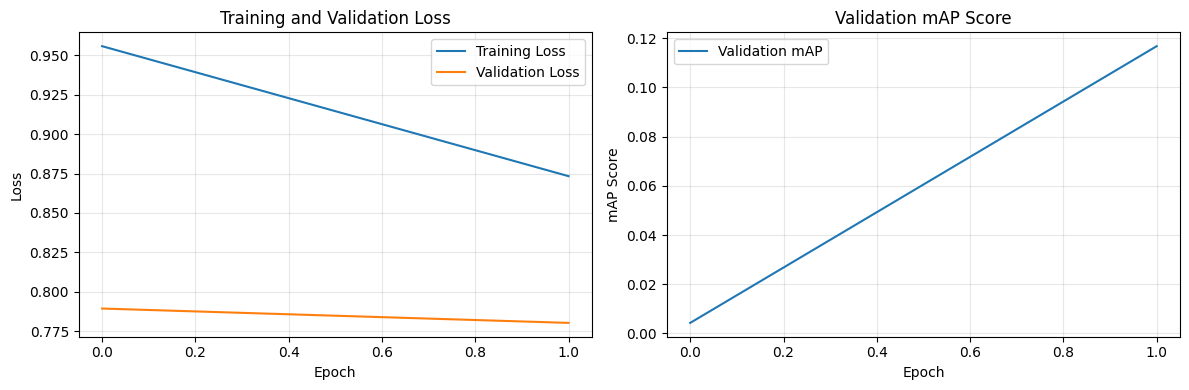

In [4]:
check_model_pipeline(train_df=train_df, test_df=test_df, model_class=SimpleObjectDetector, sample_size=500)

In [5]:
test_df["class"] = "healthy"

# Prepare data
train_loader, val_loader, test_loader, class_map, class_names = prepare_data(df=train_df, test_df=test_df, batch_size=32)

# Create model
model = SimpleObjectDetector(len(class_names))

# Train model
trained_model, history = train_model(
    model, 
    train_loader, 
    val_loader, 
    class_names, 
    num_epochs=20, 
    learning_rate=0.001, 
    optimizer_name='adamw',
    use_multi_gpu=False,
    output_model_dir='object_detection_models',
    grad_clip=10.0)

Train dataset: 4423 images
Validation dataset: 1106 images
Test dataset: 1626 images
Number of classes: 3
Using 4 worker threads for data loading
Images normalized with mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
Using device: cuda
Total parameters: 3,469,121
Trainable parameters: 3,469,121
Epoch 1/20

Training Epoch 1/20
  Batch 10/139, Running Loss: 2.9550
  Loss Breakdown: loss_classifier: 0.7326  loss_box_reg: 0.1812  loss_objectness: 0.3529  loss_rpn_box_reg: 0.0605  loss_l2: 0.0053  
  Batch 20/139, Running Loss: 2.0522
  Loss Breakdown: loss_classifier: 0.8461  loss_box_reg: 0.4763  loss_objectness: 0.2557  loss_rpn_box_reg: 0.0452  loss_l2: 0.0056  
  Batch 30/139, Running Loss: 1.8311
  Loss Breakdown: loss_classifier: 0.5927  loss_box_reg: 0.4710  loss_objectness: 0.2529  loss_rpn_box_reg: 0.0472  loss_l2: 0.0058  
  Batch 40/139, Running Loss: 1.7195
  Loss Breakdown: loss_classifier: 0.5971  loss_box_reg: 0.4504  loss_objectness: 0.2303  loss_rpn_box_reg: 0.0438  

SystemExit: 0

/home/jason-server/Documents/amini_cocoa_contamination/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
